In [2]:
!pip install yfinance pandas statsmodels matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 15.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 20.9 MB/s eta 0:00:01
   ----


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore') 

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11




#### FASE 1: RECOLECCIÓN Y LIMPIEZA DE DATOS 

In [6]:

print('1. Descargando datos \n ')

tickers = {
    'Repsol': 'REP.MC',
    'IBEX35': '^IBEX',
    'Brent': 'BZ=F',
    'EURUSD': 'EURUSD=X',
    'VIX': '^VIX',       
    'Tipos10Y': '^TNX'   
}

lista_dfs = []

for nombre, ticker in tickers.items():
    df_aux = yf.download(ticker, start='2023-03-25', end='2026-03-25', progress=False)
    
    # Selección de columna robusta (por si falla Adj Close), usando MultiIndex
    col = ('Adj Close', ticker) if ('Adj Close', ticker) in df_aux.columns else ('Close', ticker)
    
    # Extraemos solo la columna que queremos y le ponemos el nombre del activo
    serie_precios = df_aux[col].rename(nombre)
    lista_dfs.append(serie_precios)

# join='inner' asegura que solo se mantengan las fechas comunes a todos los DataFrames
datos_diarios = pd.concat(lista_dfs, axis=1, join='inner')

# Eliminamos cualquier nulo residual y ordenamos cronológicamente
datos_diarios = datos_diarios.dropna().sort_index()

print(datos_diarios.head()) 

print(f'\nDías a procesar {len(datos_diarios)} \n')
print(f'Rango temporal: {datos_diarios.index.min().date()} a {datos_diarios.index.max().date()} \n')



1. Descargando datos 
 
               Repsol       IBEX35      Brent    EURUSD        VIX  Tipos10Y
Date                                                                        
2023-03-27  11.405010  8906.099609  78.120003  1.077819  20.600000     3.528
2023-03-28  11.634092  8944.299805  78.650002  1.080707  19.969999     3.564
2023-03-29  11.691363  9070.700195  78.279999  1.083952  19.120001     3.566
2023-03-30  11.675000  9207.099609  79.269997  1.084363  19.020000     3.551
2023-03-31  11.605458  9232.500000  79.769997  1.090465  18.700001     3.494

Días a procesar 742 

Rango temporal: 2023-03-27 a 2026-03-24 



Primeras filas del DataFrame Final:
               Repsol       IBEX35      Brent    EURUSD        VIX  \
Date                                                                 
2023-03-27  11.405010  8906.099609  78.120003  1.077819  20.600000   
2023-03-28  11.634092  8944.299805  78.650002  1.080707  19.969999   
2023-03-29  11.691363  9070.700195  78.279999  1.083952  19.120001   
2023-03-30  11.675000  9207.099609  79.269997  1.084363  19.020000   
2023-03-31  11.605458  9232.500000  79.769997  1.090465  18.700001   

            Forward_10Y_EU  
Date                        
2023-03-27         2.70883  
2023-03-28         2.72085  
2023-03-29         2.75761  
2023-03-30         2.83870  
2023-03-31         2.82819  


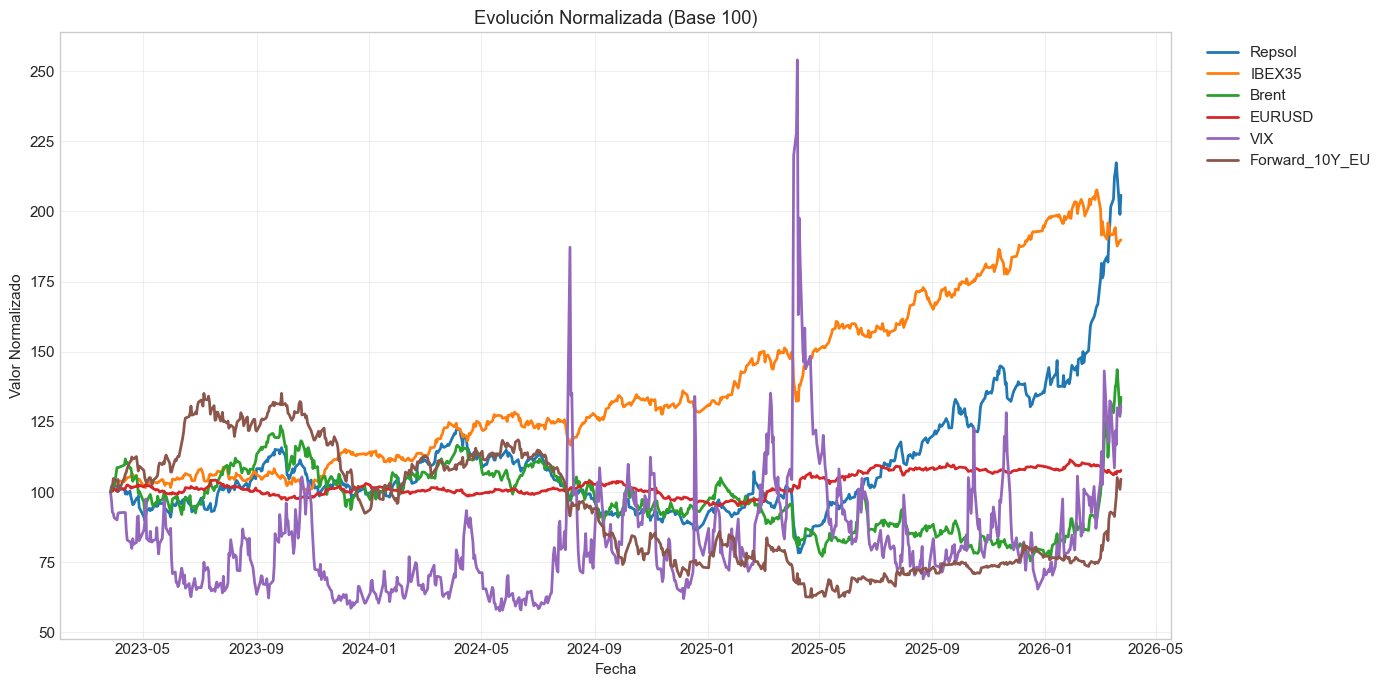

<Figure size 1400x800 with 0 Axes>

In [25]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ==========================================
# 1. PROCESAMIENTO DEL TSV (Curva Eurozona)
# ==========================================
# Nota: Usamos index_col=0 para que la primera columna sea el índice
df_yield = pd.read_csv('yield_curve.tsv', sep='\t', index_col=0)

# Al transponer, los metadatos se convierten en los nombres de las columnas.
df_yield = df_yield.T

# Seleccionamos por posición [0] para convertirla en Serie y luego en DataFrame limpio.
df_yield = df_yield.iloc[:, 0].to_frame() 

# Renombramos a la columna de la Eurozona
df_yield.columns = ['Forward_10Y_EU']

# Convertimos el índice a datetime y limpiamos
df_yield.index = pd.to_datetime(df_yield.index.str.strip())

# Limpieza de espacios y ':' y conversión a float
df_yield['Forward_10Y_EU'] = pd.to_numeric(
    df_yield['Forward_10Y_EU'].astype(str).str.replace(' ', '').replace(':', ''), 
    errors='coerce'
)

# Eliminamos filas sin datos
df_yield = df_yield.dropna()


# ==========================================
# 2. DESCARGA DE DATOS DE YAHOO FINANCE
# ==========================================
# (Se ha eliminado 'US_10Y' según tu petición)
tickers = {
    'Repsol': 'REP.MC',
    'IBEX35': '^IBEX',
    'Brent': 'BZ=F',
    'EURUSD': 'EURUSD=X',
    'VIX': '^VIX'
}

lista_dfs = []

for nombre, ticker in tickers.items():
    df_aux = yf.download(ticker, start='2023-03-25', end='2026-03-25', progress=False)
    # yfinance ahora devuelve MultiIndex en las columnas, manejamos esto:
    col = ('Adj Close', ticker) if ('Adj Close', ticker) in df_aux.columns else ('Close', ticker)
    serie_precios = df_aux[col].rename(nombre)
    lista_dfs.append(serie_precios)

datos_diarios = pd.concat(lista_dfs, axis=1, join='inner')


# ==========================================
# 3. UNIÓN DE LOS DATOS Y NORMALIZACIÓN
# ==========================================
# Unimos los datos de Yahoo Finance con el Forward de la Eurozona
df_final = datos_diarios.join(df_yield, how='inner')
df_final = df_final.dropna()

print("Primeras filas del DataFrame Final:")
print(df_final.head())

# NORMALIZACIÓN (Base 100)
# Dividimos cada fila por el valor de la primera fila y multiplicamos por 100.
# Así todas las variables empiezan en 100 y podemos comparar su evolución relativa.
df_norm = (df_final / df_final.iloc[0]) * 100


# ==========================================
# 4. GRÁFICO COMPARATIVO DE TODAS LAS FEATURES
# ==========================================
plt.figure(figsize=(14, 7))

for columna in df_norm.columns:
    plt.plot(df_norm.index, df_norm[columna], label=columna, linewidth=2)

plt.title('Evolución Normalizada (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor Normalizado')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("Evolucion_precios.png", format='png', dpi=300)


ANÁLISIS EXPLORATORIO

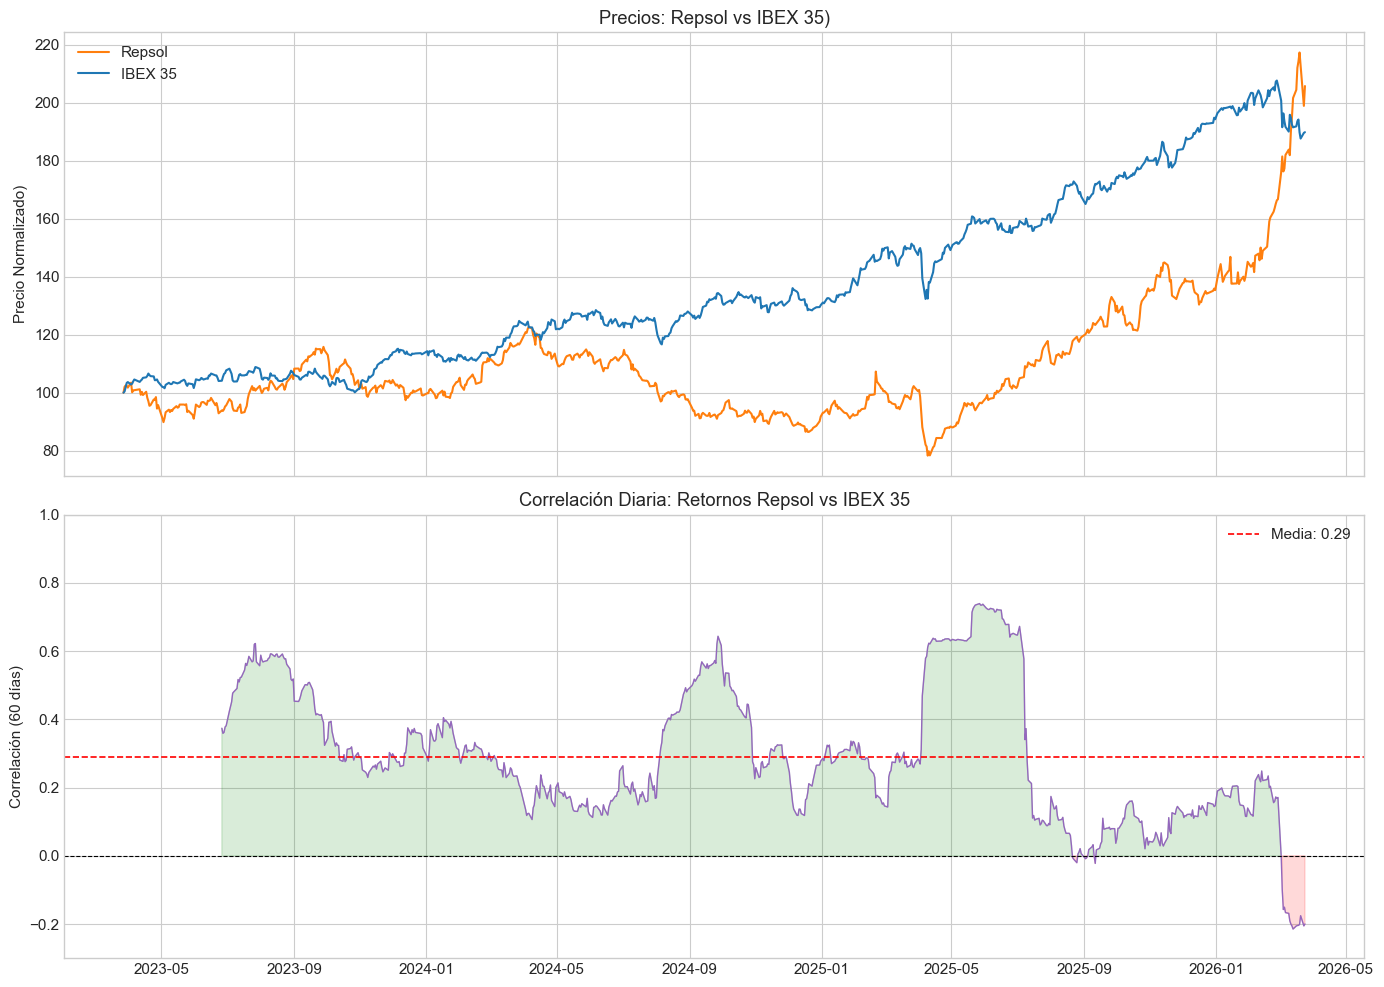

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel superior: Precios Normalizados (Base 100)
repsol_norm = datos_diarios['Repsol'] / datos_diarios['Repsol'].iloc[0] * 100
ibex_norm = datos_diarios['IBEX35'] / datos_diarios['IBEX35'].iloc[0] * 100

axes[0].plot(datos_diarios.index, repsol_norm, color='#ff7f0e', linewidth=1.5, label='Repsol')
axes[0].plot(datos_diarios.index, ibex_norm, color='#1f77b4', linewidth=1.5, label='IBEX 35')
axes[0].set_ylabel('Precio Normalizado)')
axes[0].set_title('Precios: Repsol vs IBEX 35)')
axes[0].legend()

# Grafico 2: Correlación (60 días) sobre retornos logarítmicos
ret_diarios_repsol = np.log(datos_diarios['Repsol'] / datos_diarios['Repsol'].shift(1))
ret_diarios_ibex = np.log(datos_diarios['IBEX35'] / datos_diarios['IBEX35'].shift(1))
corr_rodante = ret_diarios_repsol.rolling(window=60).corr(ret_diarios_ibex).dropna()

axes[1].plot(corr_rodante.index, corr_rodante, color='#9467bd', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(corr_rodante.mean(), color='red', linewidth=1.2, linestyle='--', label=f'Media: {corr_rodante.mean():.2f}')
axes[1].fill_between(corr_rodante.index, corr_rodante, 0, where=corr_rodante > 0, alpha=0.15, color='green')
axes[1].fill_between(corr_rodante.index, corr_rodante, 0, where=corr_rodante <= 0, alpha=0.15, color='red')
axes[1].set_ylabel('Correlación (60 días)')
axes[1].set_title('Correlación Diaria: Retornos Repsol vs IBEX 35')
axes[1].legend()
axes[1].set_ylim(-0.3, 1)

plt.tight_layout()
plt.savefig("IBEX35-REP.png", format='png', dpi=300)
plt.show()


#### FASE 2: TRANSFORMACIÓN A RENTABILIDADES SEMANALES Y ESTIMACIÓN DEL MODELO OLS

In [26]:
# ==========================================
# 5. TRANSFORMACIÓN A SEMANAL
# ==========================================
datos_semanales = df_final.resample('W-FRI').last()

# PRECIOS → RENTABILIDADES
precios_cols = ['Repsol', 'IBEX35', 'Brent', 'EURUSD', 'VIX']
rentabilidades_precios = datos_semanales[precios_cols].pct_change()

# TIPOS → CAMBIOS (IMPORTANTE)
tipos_cols = ['Forward_10Y_EU']
cambios_tipos = datos_semanales[tipos_cols].diff() * 100  # en basis points

# UNIÓN FINAL
rentabilidades = pd.concat([rentabilidades_precios, cambios_tipos], axis=1).dropna()

# ==========================================
# 6. DEFINICIÓN DEL MODELO
# ==========================================
Y = rentabilidades['Repsol']

features = ['IBEX35', 'Brent', 'EURUSD', 'VIX', 'Forward_10Y_EU']
print(f'Features seleccionadas: {features}\n')

X = rentabilidades[features]
X = sm.add_constant(X)

Features seleccionadas: ['IBEX35', 'Brent', 'EURUSD', 'VIX', 'Forward_10Y_EU']



Ajustamos Regresión Lineal Múltiple

In [27]:

modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Repsol   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     32.52
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.31e-22
Time:                        17:30:05   Log-Likelihood:                 353.71
No. Observations:                 156   AIC:                            -695.4
Df Residuals:                     150   BIC:                            -677.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0019      0.002      0.

Ver correlaciones entre pares de features consideradas

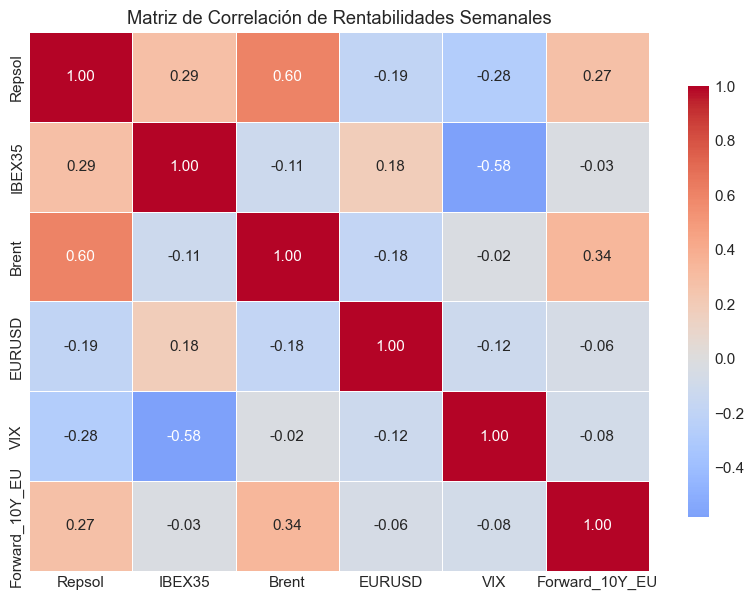

In [31]:
plt.figure(figsize=(10, 7))
matriz_corr = rentabilidades[['Repsol'] + features].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación de Rentabilidades Semanales')
plt.savefig("Matriz_Correlacion.png", format='png', dpi=300)
plt.show()

Ante el problema de la multicolinealidad se mide el factor de inflacion de la varianza, es decir que si hay multicolinealidad entonces la varianza de los coeficientes aumenta y los p-values pueden no ser correctos

Valores ssuperiores a 5 indican multicolinealidad alta pudiendo llegar a eliminar una de las variables afectadas

Esto mide correlacion de una variable con todas las demas a la vez, ya que puede que el brent no este correlacionado con el ibex ni vix pero la combinacion ssi que explique todo

In [29]:

# ==============================================================================
# FASE 3: DIAGNÓSTICO DEL MODELO (VIF, Residuos y Correlación)
# ==============================================================================
print('\n' + '='*70)
print('ANÁLISIS DE MULTICOLINEALIDAD (VIF)')
print('='*70)

# Calculamos el VIF para descartar multicolinealidad grave
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data["VIF"] = vif_data["VIF"].round(2)
print(vif_data)



ANÁLISIS DE MULTICOLINEALIDAD (VIF)
         Variable   VIF
0           const  1.12
1          IBEX35  1.58
2           Brent  1.18
3          EURUSD  1.07
4             VIX  1.55
5  Forward_10Y_EU  1.14


# --- GRÁFICO 3: ANÁLISIS DE RESIDUOS (ERRORES) ---

Diagnóstico de Residuos (Heterocedasticidad y Normalidad)


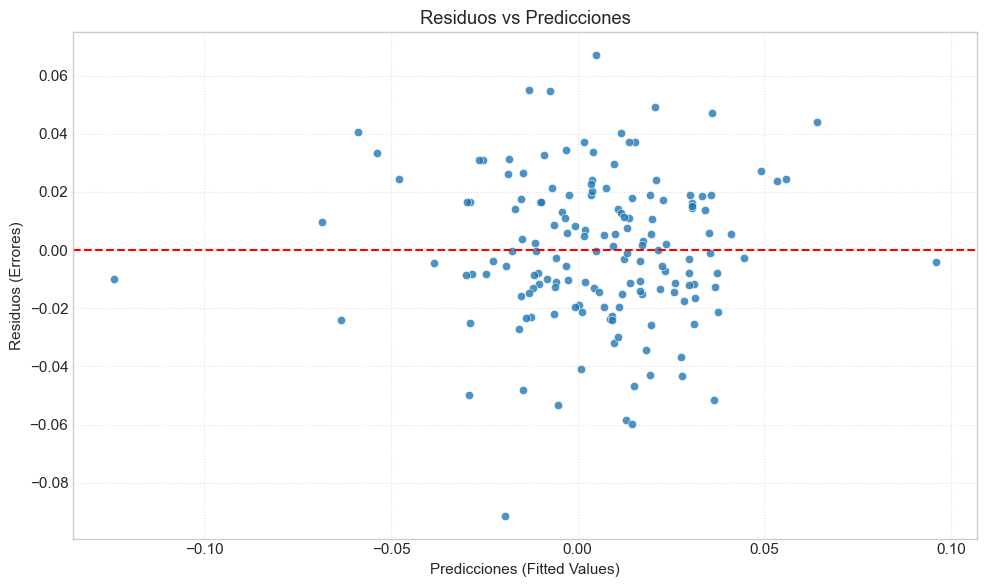

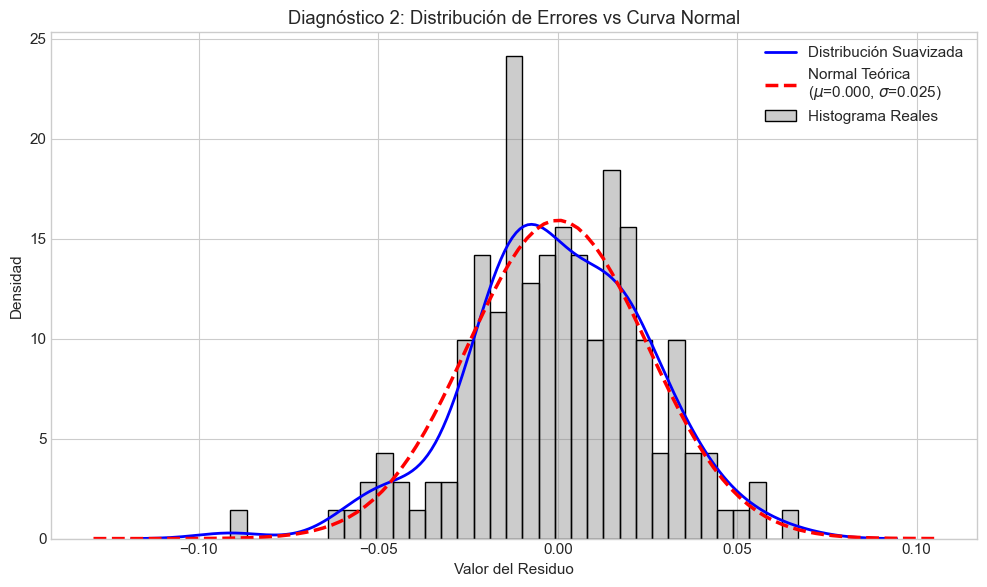

In [32]:
residuos = modelo.resid
predicciones = modelo.fittedvalues

print('Diagnóstico de Residuos (Heterocedasticidad y Normalidad)')

# GRÁFICO 1: Residuos vs Predicciones
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=predicciones, y=residuos, ax=ax1, alpha=0.8, color='#1f77b4')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_title('Residuos vs Predicciones')
ax1.set_xlabel('Predicciones (Fitted Values)')
ax1.set_ylabel('Residuos (Errores)')
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("Residuos_vs_Predicciones.png", format='png', dpi=300)
plt.show()

# GRÁFICO 2: Histograma de Residuos vs Curva Normal Teórica
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.histplot(residuos, bins=35, stat='density', ax=ax2, color='gray', alpha=0.4, label='Histograma Reales')
sns.kdeplot(residuos, ax=ax2, color='blue', linewidth=2, label='Distribución Suavizada')

# Calculamos los parámetros para la curva Normal teórica
mu, std = stats.norm.fit(residuos)
xmin, xmax = ax2.get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x_norm, mu, std)

# Pintamos la línea roja de la Normal
ax2.plot(x_norm, p_norm, color='red', linewidth=2.5, linestyle='--', label=f'Normal Teórica\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')
ax2.set_title('Diagnóstico 2: Distribución de Errores vs Curva Normal')
ax2.set_xlabel('Valor del Residuo')
ax2.set_ylabel('Densidad')
ax2.legend()
plt.tight_layout()
plt.savefig("Distribucion_Residuos.png", format='png', dpi=300)
plt.show()


No hay heterocedasticidad ya que son residuos aleatorios

La distribucion es mas empinada es decir leptocurtica, con colas mas pesadas